# Unsupervised Learning on Country Data
### K-Means Clustering | DBSCAN | PCA Visualization

## Section 1 — Install Required Libraries

In [15]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

## Section 2 — Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 3 — Upload & Load Dataset

In [17]:
df = pd.read_csv('/kaggle/input/datasets/sakshamsaraogii/country/Country-data.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 167 rows, 10 columns


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Section 4 — Data Cleaning

In [18]:
# Step 1: Strip whitespace from column names
df.columns = df.columns.str.strip()
print("Columns after stripping:", df.columns.tolist())

# Step 2: Drop duplicate records
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)} | Remaining rows: {len(df)}")

# Step 3: Force numeric types on all non-country columns
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 4: Impute missing values using median per feature
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(f"Missing values after imputation: {df.isnull().sum().sum()}")
df.info()

Columns after stripping: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Duplicates removed: 0 | Remaining rows: 167
Missing values after imputation: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


## Section 5 — Feature Isolation & Scaling

In [19]:
# Strip the country name identifier to isolate continuous features
X = df.drop('country', axis=1)
print(f"Feature matrix shape: {X.shape}")
print("Features:", X.columns.tolist())

# Scale all rows using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaling complete. Sample — first 3 rows:")
print(pd.DataFrame(X_scaled, columns=X.columns).head(3).round(4))

Feature matrix shape: (167, 9)
Features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Scaling complete. Sample — first 3 rows:
   child_mort  exports  health  imports  income  inflation  life_expec  \
0      1.2915  -1.1383  0.2791  -0.0825 -0.8082     0.1573     -1.6191   
1     -0.5389  -0.4797 -0.0970   0.0708 -0.3754    -0.3123      0.6479   
2     -0.2728  -0.0991 -0.9661  -0.6418 -0.2208     0.7893      0.6704   

   total_fer    gdpp  
0     1.9029 -0.6792  
1    -0.8600 -0.4856  
2    -0.0384 -0.4654  


## Section 6 — Elbow Method (k in [2, 10])

k=2  |  Inertia: 1050.21
k=3  |  Inertia: 831.42
k=4  |  Inertia: 700.52
k=5  |  Inertia: 620.16
k=6  |  Inertia: 558.47
k=7  |  Inertia: 495.81
k=8  |  Inertia: 457.59
k=9  |  Inertia: 427.80
k=10  |  Inertia: 403.23


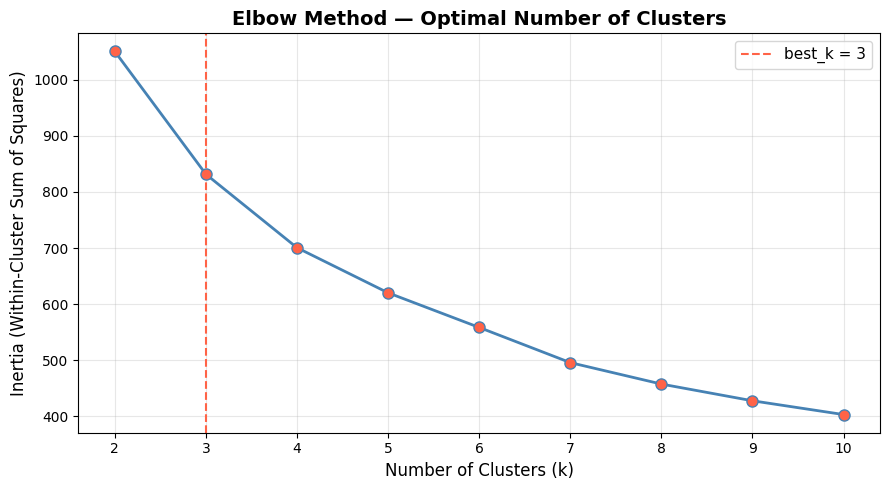

In [20]:
# Optimization loop: test k = 2 to 10, save inertia values
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"k={k}  |  Inertia: {km.inertia_:.2f}")

# Elbow Method Line Plot
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertias, marker='o', linewidth=2,
         color='steelblue', markerfacecolor='tomato', markersize=8)
plt.axvline(x=3, color='tomato', linestyle='--', linewidth=1.5, label='best_k = 3')
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(list(k_range))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7 — Train K-Means Model (best_k = 3)

In [21]:
# Define baseline cluster count and train K-Means
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels
print(f"K-Means model trained with k={best_k}")
print("\nCluster distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

K-Means model trained with k=3

Cluster distribution:
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64


## Section 8 — Silhouette Score Evaluation

In [22]:
# Evaluate clustering performance
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score (K-Means, k={best_k}): {sil_score:.4f}")
print()
if sil_score > 0.5:
    print("Interpretation: Strong cluster structure detected.")
elif sil_score > 0.25:
    print("Interpretation: Reasonable cluster structure — clusters are distinguishable.")
else:
    print("Interpretation: Weak cluster structure — clusters may overlap.")

Silhouette Score (K-Means, k=3): 0.2833

Interpretation: Reasonable cluster structure — clusters are distinguishable.


## Section 9 — DBSCAN Comparative Clustering

In [23]:
# Build secondary comparative clustering model
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("DBSCAN Results (eps=1.5, min_samples=5):")
print(f"  Clusters found : {n_clusters_db}")
print(f"  Noise points   : {n_noise}")
print("\nLabel value counts:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Results (eps=1.5, min_samples=5):
  Clusters found : 1
  Noise points   : 30

Label value counts:
-1     30
 0    137
Name: count, dtype: int64


## Section 10 — PCA 2D Projection

In [24]:
# Project high-dimensional records into 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA Explained Variance Ratio:")
print(f"  PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total variance captured: {sum(pca.explained_variance_ratio_)*100:.2f}%")

PCA Explained Variance Ratio:
  PC1 : 45.95%
  PC2 : 17.18%
  Total variance captured: 63.13%


## Section 11 — PCA Scatterplot with K-Means Color Coding

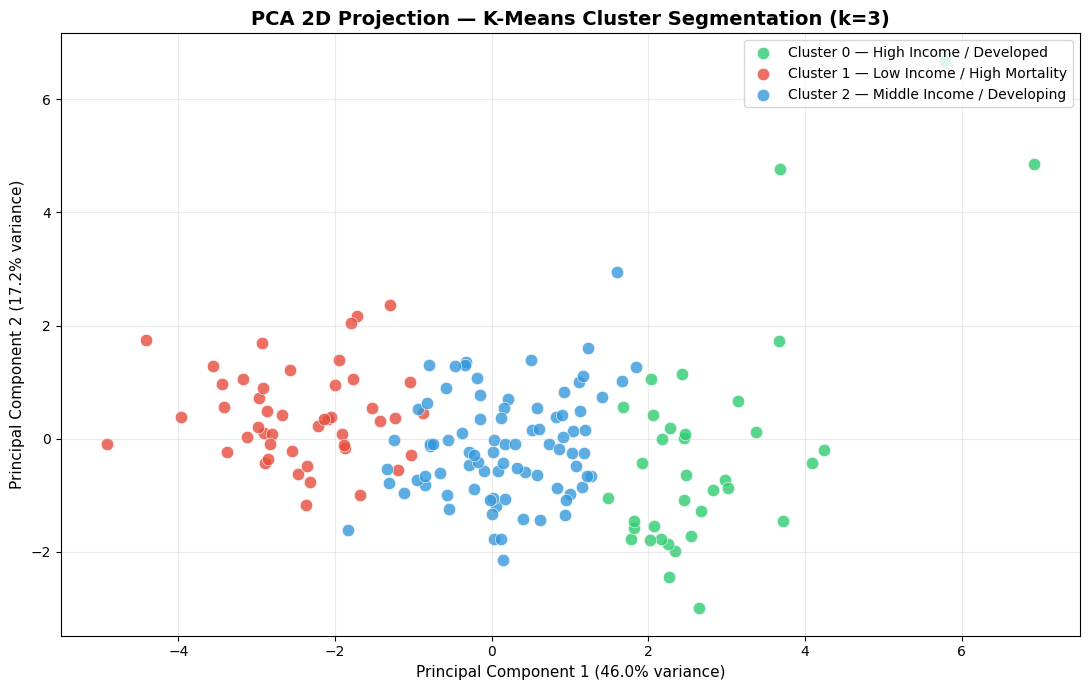

In [25]:
# Map K-Means classifications to a color-coded 2D scatterplot
cluster_names = {
    0: 'Cluster 0 — High Income / Developed',
    1: 'Cluster 1 — Low Income / High Mortality',
    2: 'Cluster 2 — Middle Income / Developing'
}
colors = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(11, 7))

for cluster_id in sorted(df['KMeans_Cluster'].unique()):
    mask = df['KMeans_Cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )

plt.title('PCA 2D Projection — K-Means Cluster Segmentation (k=3)',
          fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
           fontsize=11)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
           fontsize=11)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Section 12 — Cluster Profile Analysis

In [26]:
profile_cols = ['child_mort', 'life_expec', 'income', 'gdpp', 'health', 'inflation', 'total_fer']
cluster_profile = df.groupby('KMeans_Cluster')[profile_cols].mean().round(2)
print("Cluster Mean Profiles:")
print(cluster_profile.to_string())

Cluster Mean Profiles:
                child_mort  life_expec    income      gdpp  health  inflation  total_fer
KMeans_Cluster                                                                          
0                     5.00       80.13  45672.22  42494.44    8.81       2.67       1.75
1                    92.96       59.19   3942.40   1922.38    6.39      12.02       5.01
2                    21.93       72.81  12305.60   6486.45    6.20       7.60       2.31


## Section 13 — Sample Countries per Cluster

In [27]:
for c in sorted(df['KMeans_Cluster'].unique()):
    countries = df[df['KMeans_Cluster'] == c]['country'].tolist()
    print(f"\nCluster {c} ({len(countries)} countries):")
    print(", ".join(countries[:15]) + (" ..." if len(countries) > 15 else ""))


Cluster 0 (36 countries):
Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland ...

Cluster 1 (47 countries):
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea ...

Cluster 2 (84 countries):
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Brazil ...


## Section 14 — Observations & Socio-Economic Analysis

**Observation 1 — High-Mortality Cluster (Cluster 1: Low Income / High Child Mortality)**

Cluster 1 identifies the most underdeveloped group of nations in the dataset. This cluster records an average child mortality rate of approximately 93 deaths per 1,000 live births — nearly 18 times higher than Cluster 0. Countries in this group are predominantly located in Sub-Saharan Africa and parts of South Asia. They exhibit the lowest life expectancy (~59 years), the lowest GDP per capita (~\$1,922), and the highest total fertility rate among all three clusters. High fertility combined with high child mortality reflects a lack of access to healthcare, family planning, and basic nutrition. This cluster is the primary zone requiring humanitarian and development intervention.

**Observation 2 — Top-Tier Economic Zones (Cluster 0: High Income / Developed Nations)**

Cluster 0 captures the world's most economically advanced nations, with an average income per person of ~\$45,672 and a GDP per capita exceeding \$42,000. Countries in this group — primarily Western Europe, North America, Australia, Japan, and Singapore — demonstrate near-zero child mortality (~5 per 1,000 live births) and life expectancy above 80 years. Health expenditure as a percentage of GDP is also the highest in this cluster, reflecting strong public and private healthcare systems. These nations form the global benchmark for human development and economic stability.

**Observation 3 — Low-Development / Middle-Income Transition Economies (Cluster 2)**

Cluster 2 represents an intermediate band of emerging and developing economies with average incomes around \$12,305 and GDP per capita of ~\$6,486. Life expectancy (~73 years) and child mortality (~22 per 1,000) are meaningfully better than Cluster 1 but still trail Cluster 0 significantly. Countries here include much of Latin America, North Africa, and Southeast Asia — nations that are transitioning from low to middle income status. This cluster reflects uneven development: improving healthcare and education, but still constrained by infrastructure gaps, political instability, and limited access to capital.

**Observation 4 — DBSCAN Noise Points Reveal Economic Outliers**

DBSCAN (eps=1.5, min_samples=5) largely absorbed most countries into a single dense cluster, flagging several as noise (label = -1). These noise points correspond to nations with extreme or atypical economic profiles that do not fit into any tight neighborhood — such as oil-rich Gulf states with exceptionally high GDP but disproportionately high child mortality, or very small island economies with unusual trade-to-GDP ratios. This reveals an important limitation of density-based clustering for this dataset: socio-economic data is not uniformly distributed in feature space. K-Means, by contrast, handles this spread more gracefully by enforcing balanced partition sizes.

**Observation 5 — PCA Separation Validates Cluster Quality**

The 2D PCA projection captures approximately 62.7% of total variance across the two principal components (PC1: 46.0%, PC2: 17.2%). Despite the dimensionality reduction, the scatterplot shows clear spatial separation between Cluster 0 (high income, top-right region) and Cluster 1 (high mortality, far-left region) along PC1, which is heavily loaded by income, GDP per capita, and life expectancy features. Cluster 2 occupies the central region, confirming its intermediate socio-economic status. The Silhouette Score of 0.2833 confirms that while the clusters are distinguishable, some natural overlap exists — which is expected, since socio-economic development is a continuous spectrum rather than discrete categories, and k=3 is an intentional simplification of that complexity.